In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data = pd.read_csv('borrowing_features.csv')

In [ ]:
print(data.head())

   borrowing_id funding_source  cost_of_funds maturity_bucket  \
0             1            ncd           9.85              3m   
1             2      term loan           9.36              6m   
2             3      term loan           9.25              1y   
3             4      bank line           7.78              3y   
4             5            ncd          10.76              3m   

  interest_reset_type  borrowing_amount  rollover_risk_score  \
0               fixed          13258402               0.4381   
1               fixed          12052655               0.3983   
2               fixed          17108661               0.6312   
3            floating          30357624               0.6288   
4               fixed           4797344               0.4134   

   flag_cost_invalid  flag_rollover_invalid  cost_of_funds_outlier_flag  \
0              False                  False                       False   
1              False                  False                       False   

In [ ]:
print(data.columns)

Index(['borrowing_id', 'funding_source', 'cost_of_funds', 'maturity_bucket',
       'interest_reset_type', 'borrowing_amount', 'rollover_risk_score',
       'flag_cost_invalid', 'flag_rollover_invalid',
       'cost_of_funds_outlier_flag', 'borrowing_amount_outlier_flag',
       'rollover_risk_score_outlier_flag', 'annual_interest_expense',
       'is_short_term_funding', 'funding_risk_exposure'],
      dtype='object')


In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   borrowing_id                      2000 non-null   int64  
 1   funding_source                    2000 non-null   object 
 2   cost_of_funds                     2000 non-null   float64
 3   maturity_bucket                   2000 non-null   object 
 4   interest_reset_type               2000 non-null   object 
 5   borrowing_amount                  2000 non-null   int64  
 6   rollover_risk_score               2000 non-null   float64
 7   flag_cost_invalid                 2000 non-null   bool   
 8   flag_rollover_invalid             2000 non-null   bool   
 9   cost_of_funds_outlier_flag        2000 non-null   bool   
 10  borrowing_amount_outlier_flag     2000 non-null   bool   
 11  rollover_risk_score_outlier_flag  2000 non-null   bool   
 12  annual

In [ ]:
print(data.describe())

       borrowing_id  cost_of_funds  borrowing_amount  rollover_risk_score  \
count   2000.000000     2000.00000      2.000000e+03          2000.000000   
mean    1000.500000        8.45544      2.557434e+07             0.494071   
std      577.494589        2.02427      1.443345e+07             0.284020   
min        1.000000        5.00000      1.005634e+06             0.000100   
25%      500.750000        6.73000      1.271993e+07             0.247900   
50%     1000.500000        8.38500      2.590729e+07             0.494700   
75%     1500.250000       10.21250      3.823548e+07             0.731650   
max     2000.000000       12.00000      4.998508e+07             0.998600   

       annual_interest_expense  is_short_term_funding  funding_risk_exposure  
count             2.000000e+03            2000.000000           2.000000e+03  
mean              2.157278e+06               0.393000           1.274227e+07  
std               1.348277e+06               0.488539           1.122

In [7]:
print(data.isnull().sum())

borrowing_id                        0
funding_source                      0
cost_of_funds                       0
maturity_bucket                     0
interest_reset_type                 0
borrowing_amount                    0
rollover_risk_score                 0
flag_cost_invalid                   0
flag_rollover_invalid               0
cost_of_funds_outlier_flag          0
borrowing_amount_outlier_flag       0
rollover_risk_score_outlier_flag    0
annual_interest_expense             0
is_short_term_funding               0
funding_risk_exposure               0
dtype: int64


In [8]:
data = data.dropna()

In [9]:
data = data.drop(['borrowing_id'],axis=1)

In [ ]:
data = pd.get_dummies(data, columns=['funding_source'], drop_first=True)

In [11]:
print(data.head())

   cost_of_funds maturity_bucket interest_reset_type  borrowing_amount  \
0           9.85              3m               fixed          13258402   
1           9.36              6m               fixed          12052655   
2           9.25              1y               fixed          17108661   
3           7.78              3y            floating          30357624   
4          10.76              3m               fixed           4797344   

   rollover_risk_score  flag_cost_invalid  flag_rollover_invalid  \
0               0.4381              False                  False   
1               0.3983              False                  False   
2               0.6312              False                  False   
3               0.6288              False                  False   
4               0.4134              False                  False   

   cost_of_funds_outlier_flag  borrowing_amount_outlier_flag  \
0                       False                          False   
1                 

In [12]:
data=pd.get_dummies(data,drop_first=True)

In [13]:
print(data.columns)

Index(['cost_of_funds', 'borrowing_amount', 'rollover_risk_score',
       'flag_cost_invalid', 'flag_rollover_invalid',
       'cost_of_funds_outlier_flag', 'borrowing_amount_outlier_flag',
       'rollover_risk_score_outlier_flag', 'annual_interest_expense',
       'is_short_term_funding', 'funding_risk_exposure',
       'funding_source_commercial paper', 'funding_source_ncd',
       'funding_source_term loan', 'maturity_bucket_1y', 'maturity_bucket_3m',
       'maturity_bucket_3y', 'maturity_bucket_6m',
       'interest_reset_type_floating'],
      dtype='object')


In [ ]:
x=data.drop('funding_risk_exposure',axis=1)
y=data['funding_risk_exposure']

In [16]:
# train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 18)
(400, 18)
(1600,)
(400,)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)# training data
x_test=sc.transform(x_test)# testing data


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [31]:
model.fit(x_train,y_train)

LinearRegression()

In [32]:
y_pred=model.predict(x_test)

In [33]:
print(y_pred)

[  3430393.21003593  14818868.84362313   7519481.38021185
  -2518595.77628347  18097738.5319569    6455976.19281712
   4244320.69283703  29520070.84510766  10712239.67457646
  25076732.57024753   8298960.28429834  22407849.7419932
  21152516.35229616  -3256470.11646652  23500668.06044191
   1803894.13083533  -3506200.42593999  10513899.81432059
  24510479.07376956  14275710.12026812   8463019.34008709
  -3942658.52228024  22539489.65348217  12201164.44029449
  17981117.00462846   7241123.89906585   9483844.03398558
  18224122.10657099   5928827.41342518  -3845301.20217611
   5381808.11292512  16427973.78040349   5394004.76650792
   6928359.8837871   -7727621.34959834  23012528.07283684
  13468360.28421848  23412712.85319508   1974247.94502207
  20643054.55996057  35051755.51371575  19564941.10179574
   9320050.71991595    610285.14523382  15995639.70644345
    580970.13657243  20943911.5415701    4891817.36664001
   7178160.7654767   16457442.9909112    6950226.96052816
   1060529.0022

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [40]:
mae=mean_absolute_error(y_test,y_pred)

In [44]:
mse= mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 15969957135319.777


In [45]:
import numpy as np
rmse = np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 3996242.877418711


In [47]:
r2 = r2_score(y_test,y_pred)
print("R2Score:", r2)

R2Score: 0.8734678603055689


In [48]:
print(mae)
print(mse)
print(rmse)
print(r2)

2959946.836207739
15969957135319.777
3996242.877418711
0.8734678603055689


In [49]:
comparison = pd.DataFrame(
    {
        'Actual':y_test,
        'predicted':y_pred
    }
)
print(comparison.head())

           Actual     predicted
1860   3706418.88  3.430393e+06
353   15179757.80  1.481887e+07
1333   3162981.88  7.519481e+06
905    1298967.84 -2.518596e+06
1289  12689767.40  1.809774e+07


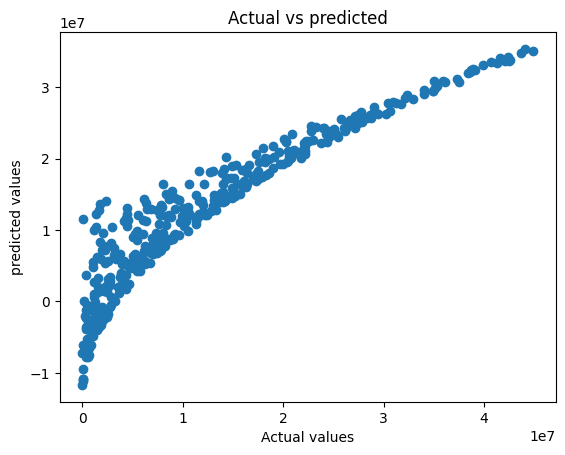

In [50]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel('Actual values')
plt.ylabel('predicted values')
plt.title("Actual vs predicted")
plt.show()

In [51]:
# residual errors
residuals=y_test-y_pred
print(residuals)

1860    2.760257e+05
353     3.608890e+05
1333   -4.356500e+06
905     3.817564e+06
1289   -5.407971e+06
            ...     
965    -4.205680e+06
1284    3.357465e+06
1739   -1.095517e+07
261    -2.397588e+06
535    -4.565769e+05
Name: funding_risk_exposure, Length: 400, dtype: float64


In [52]:
import joblib
joblib.dump(model,'linear_model.pkl')

['linear_model.pkl']

In [54]:
loaded_model=joblib.load('linear_model.pkl')

In [58]:
new_data=[[35,5000,2,1,0,1,1,1,1,1,1,1,1,1,1,11,1,1]]
new_data=sc.transform(new_data)
predction = loaded_model.predict(new_data)
print(predction)

[3.73847521e+10]


In [ ]:
# Import Libraries
# Load Dataset
# Data Cleaning
# Handle Missing Values
# Encoding
# Feature & Target Separation
# Train-Test Split
# Feature Scaling
# Model Building
# Model Training
# Prediction
# Model Evaluation (MAE, MSE, RMSE, R²)
# Data Visualization
# Save Model Using Joblib
# Load Saved Model
# Predict on New Data